# SISPS-EXP-SOH Depth of Discharge

Full Depth of Discharge curves.

In [35]:
# Always reload these user modules, else kernel restart is needed
import importlib
import Lib.plot, Lib.dataImport

for module in [Lib.plot, Lib.dataImport]:
    importlib.reload(module)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from concurrent import futures

from typing import List, Dict, Tuple

import darkdetect

plt.rcdefaults()

if darkdetect.isDark():
    plt.style.use("dark_background")

plt.rcParams.update(
    {
        "figure.dpi": 300,
        "figure.figsize": (8, 5),
    }
)

%config InlineBackend.figure_formats = ['svg']

from matplotlib import cycler

default_cycler = plt.rcParams["axes.prop_cycle"]
colors = default_cycler.by_key()["color"]
line_styles = ["-", "--", "-.", ":"]
combined_cycler = cycler(linestyle=line_styles) * cycler(color=colors)

plt.rcParams["axes.prop_cycle"] = combined_cycler

## Data Import

In [ ]:
from Lib.dataImport import read_lcv_file

DATA_DIR = "../Data/"
PLOTS_DIR = "../Plots/DoD"


def find_dod_files(data_dir) -> List[str]:
    """
    Find all Depth of Data Files within the `data_dir` directory based folder structure and file naming conventions.
    """
    files = []

    for root, dirs, filenames in os.walk(data_dir):
        if root.split("/")[-1] != "DoD":
            continue

        for filename in filenames:
            if "UCT003-DOD-C" in filename and filename.endswith(".csv"):
                files.append(os.path.join(root, filename))

    files.sort()

    return files


def import_dod_data(data_dir: str) -> List[pd.DataFrame]:
    """
    Import all Depth of Discharge Data from the `data_dir` directory.
    """
    dod_files = find_dod_files(data_dir)

    dod_data = []

    for file in dod_files:
        df = read_lcv_file(file)
        dod_data.append(df)

    return dod_data


dod_data = import_dod_data(DATA_DIR)

## Preprocessing

In [38]:
# Anomaly on C06 S02:
# Battery was connected in reverse polarity.
# Test device halted, battery disconnected and reconnected in correct polarity.
# Erroneous data line should be deleted.
for i, df in enumerate(dod_data):
    if df.attrs["battery"] == "C06" and df.attrs["stage"] == "S02":
        dod_data[i] = df[df["Voltage"] > 0]
        print("Anomaly removed from C06 S02")
        print(dod_data[i].head())
        break

Anomaly removed from C06 S02
   Total Time  Cycle  Loop Counter #1  Loop Counter #2  Loop Counter #3  Step  \
1        30.0      1                1                1                1     1   
2        60.0      1                1                1                1     1   
3        90.0      1                1                1                1     1   
4       120.0      1                1                1                1     1   
5       150.0      1                1                1                1     1   

   Step time  Current  Voltage  Power  Amp-Hours  Mode Data Acquisition Flag  
1       30.0    -1.57   12.262  -19.2      -0.01  DCHG                        
2       60.0    -1.57   12.249  -19.2      -0.02  DCHG                        
3       90.0    -1.57   12.243  -19.2      -0.03  DCHG                        
4      120.0    -1.57   12.239  -19.1      -0.05  DCHG                        
5      150.0    -1.57   12.236  -19.1      -0.06  DCHG                        


In [39]:
# Errors in S07 C13/C14 and S09 C10/C11
# Pairs of batteries were connected to the wrong channels, and were therefore swapped.
# An apparent increase in capacity in one battery, and near equal loss in the other, reveal the error.
# Correct this by swapping the dataframes and amending necessary attributes.

for i, df in enumerate(dod_data):

    def swap_batteries(df1, df2):
        # Swap the dataframes
        df_temp = df1.copy()
        df1 = df2.copy()
        df2 = df_temp.copy()
        # Swap the attributes
        temp_attrs = df1.attrs.copy()
        df1.attrs = df2.attrs.copy()
        df2.attrs = temp_attrs.copy()
        return df1, df2

    if (
        df.attrs["battery"] == "C13"
        and dod_data[i + 1].attrs["battery"] == "C14"
        and df.attrs["stage"] == "S07"
    ) or (
        df.attrs["battery"] == "C10"
        and dod_data[i + 1].attrs["battery"] == "C11"
        and df.attrs["stage"] == "S09"
    ):
        dod_data[i], dod_data[i + 1] = swap_batteries(dod_data[i], dod_data[i + 1])
        print(
            f"Swapped batteries {dod_data[i].attrs['battery']} and {dod_data[i + 1].attrs['battery']} of stage {dod_data[i].attrs['stage']}"
        )

Swapped batteries C13 and C14 of stage S07
Swapped batteries C10 and C11 of stage S09


## Depth of Discharge Values

In [40]:
for df in dod_data:
    dod = df["Amp-Hours"].min()
    print(f"{df.attrs['test']}: {dod:.2f} Ah")

UCT003-DOD-C01-S00-2: -6.36 Ah
UCT003-DOD-C02-S00-2: -6.96 Ah
UCT003-DOD-C03-S00-2: -6.88 Ah
UCT003-DOD-C04-S00-2: -7.06 Ah
UCT003-DOD-C05-S00-2: -6.91 Ah
UCT003-DOD-C06-S00-2: -6.27 Ah
UCT003-DOD-C07-S00-2: -7.07 Ah
UCT003-DOD-C08-S00: -6.25 Ah
UCT003-DOD-C09-S00: -6.61 Ah
UCT003-DOD-C10-S00: -6.90 Ah
UCT003-DOD-C11-S00: -6.56 Ah
UCT003-DOD-C12-S00: -6.08 Ah
UCT003-DOD-C13-S00: -6.85 Ah
UCT003-DOD-C14-S00: -6.15 Ah
UCT003-DOD-C01-S01: -6.07 Ah
UCT003-DOD-C02-S01: -6.64 Ah
UCT003-DOD-C03-S01: -6.61 Ah
UCT003-DOD-C04-S01: -6.72 Ah
UCT003-DOD-C05-S01: -6.76 Ah
UCT003-DOD-C06-S01: -5.92 Ah
UCT003-DOD-C07-S01: -6.94 Ah
UCT003-DOD-C08-S01: -6.00 Ah
UCT003-DOD-C09-S01: -6.31 Ah
UCT003-DOD-C10-S01: -6.79 Ah
UCT003-DOD-C11-S01: -6.27 Ah
UCT003-DOD-C12-S01: -5.83 Ah
UCT003-DOD-C13-S01: -6.71 Ah
UCT003-DOD-C14-S01: -5.98 Ah
UCT003-DOD-C01-S02: -5.79 Ah
UCT003-DOD-C02-S02: -6.66 Ah
UCT003-DOD-C03-S02: -6.55 Ah
UCT003-DOD-C04-S02: -6.53 Ah
UCT003-DOD-C05-S02: -6.68 Ah
UCT003-DOD-C06-S02: -5.96 Ah


## Basic Plotting

In [41]:
from Lib.plot import plot_current_voltage


def plot_all_dod_curves(
    dod_data: List[pd.DataFrame],
    save_dir: str | None = None,
) -> None:
    def plot_dod_curve(df, save_dir: str | None = None) -> None:
        fig = plot_current_voltage(df)
        fig.suptitle(df.attrs["test"])

        if save_dir:
            fig.savefig(f"{save_dir}/{df.attrs['test']}.png")

        plt.close(fig)

    os.makedirs(save_dir, exist_ok=True)

    with futures.ThreadPoolExecutor() as executor:
        for df in dod_data:
            executor.submit(plot_dod_curve, df, save_dir)
        # plot_dod_curve(df, save_dir)


PLOTS_DIR_ALL = os.path.join(PLOTS_DIR, "All")
plot_all_dod_curves(dod_data, PLOTS_DIR_ALL)
plt.close("all")

## Comparison of Depth of Discharge Curves

In [42]:
def plot_dod_steps(
    dfs: List[pd.DataFrame],
) -> Tuple[plt.Figure, plt.Figure, plt.Figure]:

    time_formatter = plt.FuncFormatter(
        lambda x, _: f"{x//3600:02.0f}:{(x%3600)//60:02.0f}"
    )
    voltage_formatter = plt.FuncFormatter(lambda x, _: f"{x:.1f} V")
    current_formatter = plt.FuncFormatter(lambda x, _: f"{x:.2f} A")
    # ampHour_formatter = plt.FuncFormatter(lambda x, _: f"{x:.0f} Ah")

    def get_pre_dod_fig() -> Tuple[plt.Figure, Dict[str, plt.Axes]]:
        fig = plt.figure(
            figsize=(18, 10),
        )
        ax = fig.subplot_mosaic(
            mosaic=[
                ["pre_discharge_voltage", "pre_recharge_voltage"],
                ["pre_discharge_voltage", "pre_recharge_current"],
            ],
        )

        ax["pre_discharge_voltage"].set_title("Pre-Discharge")
        ax["pre_recharge_voltage"].set_title("Pre-Recharge")

        ax["pre_recharge_voltage"].sharex(ax["pre_recharge_current"])

        ax["pre_discharge_voltage"].xaxis.set_major_formatter(time_formatter)
        ax["pre_recharge_voltage"].xaxis.set_major_formatter(time_formatter)
        ax["pre_recharge_current"].xaxis.set_major_formatter(time_formatter)
        ax["pre_discharge_voltage"].yaxis.set_major_formatter(voltage_formatter)
        ax["pre_recharge_voltage"].yaxis.set_major_formatter(voltage_formatter)
        ax["pre_recharge_current"].yaxis.set_major_formatter(current_formatter)

        return (fig, ax)

    fig1, ax1 = get_pre_dod_fig()

    def plot_pre_step(ax, df_discharge, df_recharge) -> None:
        if df_discharge.empty:
            return

        ax["pre_discharge_voltage"].plot(
            df_discharge["Stage time"],
            df_discharge["Voltage"],
            label=f"{df_recharge.attrs['battery']} {-df_discharge['Amp-Hours'].min():.2f} Ah",
        )

        ax["pre_recharge_voltage"].plot(
            df_recharge["Stage time"],
            df_recharge["Voltage"],
            label=f"{df_recharge.attrs['battery']} {df_recharge['Voltage'].iat[-1]:.3f} V",
        )
        ax["pre_recharge_current"].plot(
            df_recharge["Stage time"],
            df_recharge["Current"],
            label=f"{df_recharge.attrs['battery']} {df_recharge['Amp-Hours'].max():.2f} Ah",
        )

        ax["pre_discharge_voltage"].legend(title="Capacity")
        ax["pre_recharge_voltage"].legend(title="Est. EMF")
        ax["pre_recharge_current"].legend(title="Charge Accept")

    def get_dod_fig() -> Tuple[plt.Figure, List[plt.Axes]]:
        fig, ax = plt.subplots(
            1,
            2,
            figsize=(18, 10),
            gridspec_kw={"width_ratios": [3, 1]},
            sharey=True,
        )

        ax[0].set_title("Full Discharge")
        ax[1].set_title("Open Circuit Rest")

        ax[0].xaxis.set_major_formatter(time_formatter)
        ax[1].xaxis.set_major_formatter(time_formatter)
        ax[0].yaxis.set_major_formatter(voltage_formatter)

        return (fig, ax)

    fig2, ax2 = get_dod_fig()

    def plot_discharge_step(ax, df_discharge, df_rest) -> None:
        if df_discharge.empty:
            return

        ax[0].plot(
            df_discharge["Stage time"],
            df_discharge["Voltage"],
            label=f"{df_discharge.attrs['battery']} {-df_discharge['Amp-Hours'].min():.2f} Ah",
        )
        ax[1].plot(
            df_rest["Stage time"],
            df_rest["Voltage"],
            label=f"{df_rest.attrs['battery']} {df_rest['Voltage'].max():.3f} V",
        )

        ax[0].legend(title="Capacity")
        ax[1].legend(title="Est. EMF")

    def get_post_dod_fig() -> Tuple[plt.Figure, List[plt.Axes]]:
        fig, ax = plt.subplots(
            2,
            1,
            figsize=(12, 10),
            sharex=True,
        )

        ax[0].set_title("Post-Recharge")

        ax[1].xaxis.set_major_formatter(time_formatter)
        ax[0].yaxis.set_major_formatter(voltage_formatter)
        ax[1].yaxis.set_major_formatter(current_formatter)

        return (fig, ax)

    fig3, ax3 = get_post_dod_fig()

    def plot_post_step(ax, df_recharge) -> None:
        if df_recharge.empty:
            return

        ax[0].plot(
            df_recharge["Stage time"],
            df_recharge["Voltage"],
            label=f"{df_recharge.attrs['battery']} {df_recharge['Voltage'].iat[-1]:.3f} V",
        )
        ax[1].plot(
            df_recharge["Stage time"],
            df_recharge["Current"],
            label=f"{df_recharge.attrs['battery']} {df_recharge['Amp-Hours'].max():.2f} Ah",
        )

        ax[0].legend(title="Est. EMF")
        ax[1].legend(title="Charge Accept")

    for df in dfs:
        df_pre_discharge = df[(df["Step"] <= 1) & (df["Loop Counter #1"] == 1)].copy()
        df_pre_recharge = df[
            (df["Step"] >= 3) & (df["Step"] <= 7) & (df["Loop Counter #1"] == 1)
        ].copy()
        df_full_discharge = df[(df["Step"] == 1) & (df["Loop Counter #1"] == 2)].copy()
        df_full_discharge_rest = df[
            (df["Step"] == 2) & (df["Loop Counter #1"] == 2)
        ].copy()
        df_post_recharge = df[(df["Step"] >= 3) & (df["Loop Counter #1"] == 2)].copy()

        for df_stage in [
            df_pre_discharge,
            df_pre_recharge,
            df_full_discharge,
            df_full_discharge_rest,
            df_post_recharge,
        ]:
            df_stage["Stage time"] = (
                df_stage["Total Time"] - df_stage["Total Time"].min()
            )

        plot_pre_step(ax1, df_pre_discharge, df_pre_recharge)
        plot_discharge_step(ax2, df_full_discharge, df_full_discharge_rest)
        plot_post_step(ax3, df_post_recharge)

    fig1.tight_layout()
    fig2.tight_layout()
    fig3.tight_layout()

    return (fig1, fig2, fig3)


# Group DataFrames by Stage
from itertools import groupby

dod_data_by_stage = [
    list(group) for key, group in groupby(dod_data, lambda x: x.attrs["stage"])
]

for dfs_stage in dod_data_by_stage:
    stage = dfs_stage[0].attrs["stage"]
    fig1, fig2, fig3 = plot_dod_steps(dfs_stage)

    fig1.savefig(f"{PLOTS_DIR}/UCT003-DOD-{stage}-PRE-DSCH-CRG.png")
    fig2.savefig(f"{PLOTS_DIR}/UCT003-DOD-{stage}-FULL-DSCH.png")
    fig3.savefig(f"{PLOTS_DIR}/UCT003-DOD-{stage}-POST-CRG.png")
    plt.close("all")

| Battery   |   S00 |   S01 |   S02 |   S03 |   S04 |   S05 |   S06 |   S07 |   S08 |   S09 |   S10 |
|:----------|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|------:|
| C01       |  6.36 |  6.07 |  5.79 |  5.6  |  5.58 |  5.48 |  5.46 |  5.4  |  5.31 |  5.25 |  5.19 |
| C02       |  6.96 |  6.64 |  6.66 |  6.61 |  6.56 |  6.44 |  6.42 |  6.31 |  6.21 |  6.06 |  6.03 |
| C03       |  6.88 |  6.61 |  6.55 |  6.46 |  6.36 |  6.19 |  6.15 |  6.03 |  5.95 |  5.75 |  5.71 |
| C04       |  7.06 |  6.72 |  6.53 |  6.32 |  6.09 |  5.85 |  5.66 |  5.45 |  5.35 |  5.08 |  4.97 |
| C05       |  6.91 |  6.76 |  6.68 |  6.59 |  6.48 |  6.37 |  6.34 |  6.19 |  6    |  5.88 |  5.9  |
| C06       |  6.27 |  5.92 |  5.96 |  5.94 |  5.84 |  5.66 |  5.78 |  5.66 |  5.56 |  5.51 |  5.44 |
| C07       |  7.07 |  6.94 |  6.96 |  6.93 |  6.77 |  6.61 |  6.74 |  6.62 |  6.56 |  6.47 |  6.34 |
| C08       |  6.25 |  6    |  5.84 |  5.6  |  5.63 |  5.47 |  5.53 |  5.4  |  5.3

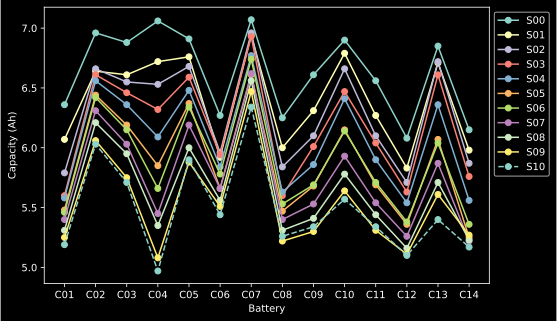

In [43]:
from tabulate import tabulate

dod_data_table = []
for df in dod_data:
    dod_data_table.append(
        {
            "Battery": df.attrs["battery"],
            "Stage": df.attrs["stage"],
            "Capacity": -(df["Amp-Hours"]).min(),
        }
    )

dod_data_table = pd.DataFrame(dod_data_table).pivot(
    index="Battery", columns="Stage", values="Capacity"
)
print(tabulate(dod_data_table, headers="keys", tablefmt="pipe"))


# Plot DoD Data
def plot_dod_line(
    data_table: pd.DataFrame,
    ylabel: str = "Capacity (Ah)",
    yaxis_formatter: plt.Formatter = None,
    **kwargs: Dict[str, str],
) -> plt.Figure:
    fig, ax = plt.subplots()

    data_table.plot(
        kind="line",
        ax=ax,
        marker="o",
        **kwargs,
    )
    ax.set_ylabel(ylabel)

    if yaxis_formatter:
        ax.yaxis.set_major_formatter(yaxis_formatter)

    plt.xticks(range(len(data_table.index)), data_table.index)  # Show all x-ticks

    # Place legend outside of plot
    ax.legend(
        loc="upper left",
        bbox_to_anchor=(1, 1),
    )

    return fig


_ = plot_dod_line(dod_data_table)

| Battery   |   S00 |      S01 |      S02 |      S03 |      S04 |      S05 |      S06 |      S07 |      S08 |      S09 |      S10 |
|:----------|------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|
| C01       |     1 | 0.954403 | 0.910377 | 0.880503 | 0.877358 | 0.861635 | 0.858491 | 0.849057 | 0.834906 | 0.825472 | 0.816038 |
| C02       |     1 | 0.954023 | 0.956897 | 0.949713 | 0.942529 | 0.925287 | 0.922414 | 0.906609 | 0.892241 | 0.87069  | 0.866379 |
| C03       |     1 | 0.960756 | 0.952035 | 0.938953 | 0.924419 | 0.899709 | 0.893895 | 0.876453 | 0.864826 | 0.835756 | 0.829942 |
| C04       |     1 | 0.951841 | 0.924929 | 0.895184 | 0.862606 | 0.828612 | 0.8017   | 0.771955 | 0.75779  | 0.719547 | 0.703966 |
| C05       |     1 | 0.978292 | 0.966715 | 0.95369  | 0.937771 | 0.921852 | 0.917511 | 0.895803 | 0.868307 | 0.850941 | 0.853835 |
| C06       |     1 | 0.944179 | 0.950558 | 0.947368 | 0.931419 | 0.902711 |

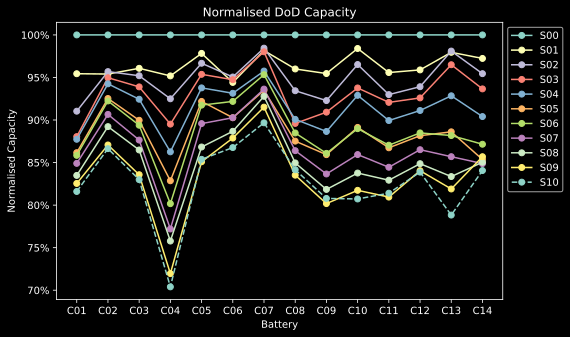

In [44]:
# Normalize DoD Data with S00 as reference
dod_normalised = dod_data_table.copy()
dod_normalised = dod_normalised.div(dod_normalised["S00"], axis=0)

print(tabulate(dod_normalised, headers="keys", tablefmt="pipe"))
normalised_dod_fig = plot_dod_line(dod_normalised)
normalised_dod_fig.axes[0].set_ylabel("Normalised Capacity")
normalised_dod_fig.axes[0].set_title("Normalised DoD Capacity")
# Set y-axis formatter to percentage
normalised_dod_fig.axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

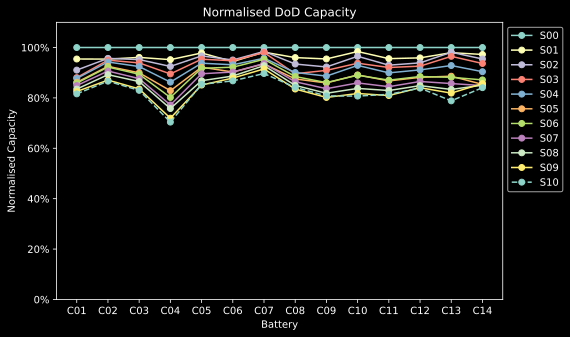

In [45]:
normalised_dod_fig.axes[0].set_ylim(0, 1.1)
normalised_dod_fig

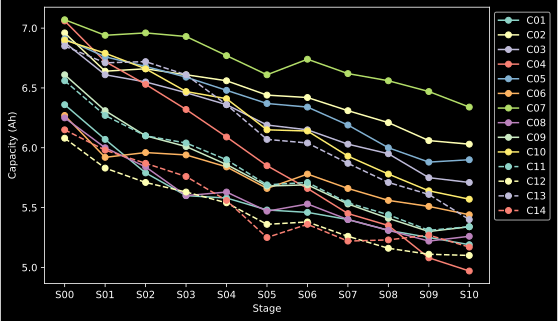

In [46]:
# Pivot DoD Data to be Stage as rows and Battery as columns
dod_data_by_stage = dod_data_table.transpose()
dod_data_by_stage_normalised = dod_normalised.transpose()

# Plot the data with the updated cycler
_ = plot_dod_line(dod_data_by_stage)

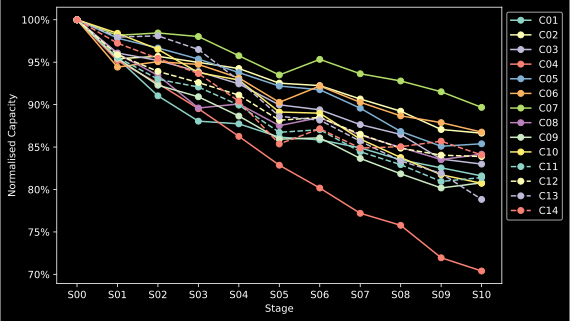

In [47]:
normalised_dod_by_stage_fig = plot_dod_line(dod_data_by_stage_normalised)
normalised_dod_by_stage_fig.axes[0].set_ylabel("Normalised Capacity")
normalised_dod_by_stage_fig.axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

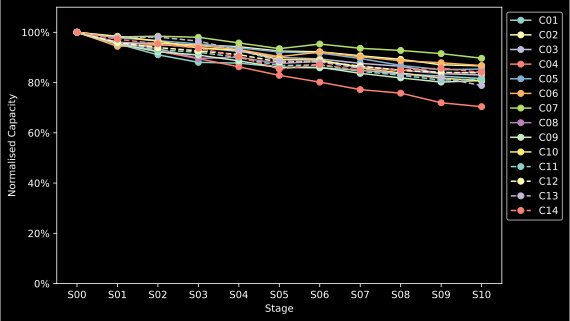

In [48]:
normalised_dod_by_stage_fig.axes[0].set_ylim(0, 1.1)
normalised_dod_by_stage_fig

### Stage Differential

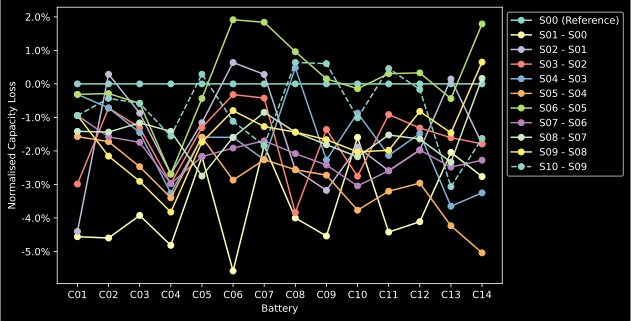

In [49]:
# for each battery, compare the capacity loss for each stage relative to the previous stage
dod_data_by_stage_normalised_diff = dod_data_by_stage_normalised.diff(axis=0)
dod_data_by_stage_normalised_diff = dod_data_by_stage_normalised_diff.fillna(0)
dod_data_by_stage_normalised_diff = dod_data_by_stage_normalised_diff.transpose()
dod_data_by_stage_normalised_diff = dod_data_by_stage_normalised_diff.rename(
    columns={
        "S00": "S00 (Reference)",
        "S01": "S01 - S00",
        "S02": "S02 - S01",
        "S03": "S03 - S02",
        "S04": "S04 - S03",
        "S05": "S05 - S04",
        "S06": "S06 - S05",
        "S07": "S07 - S06",
        "S08": "S08 - S07",
        "S09": "S09 - S08",
        "S10": "S10 - S09",
    }
)

_ = plot_dod_line(
    dod_data_by_stage_normalised_diff,
    ylabel="Normalised Capacity Loss",
    yaxis_formatter=plt.FuncFormatter(lambda x, _: f"{x:.1%}"),
)

### Equal Temperature, Differential Time Conditions

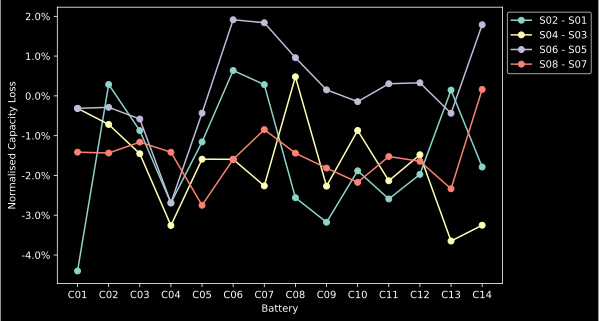

In [50]:
# S02 - S01, S04 - S03, S06 - S05, S08 - S07, S10 - S09
dod_data_by_stage_normalised_diff_same_temperature = dod_data_by_stage_normalised_diff[
    dod_data_by_stage_normalised_diff.columns[
        dod_data_by_stage_normalised_diff.columns.str.contains("S0[2468] - S0[1357]")
    ]
]

_ = plot_dod_line(
    dod_data_by_stage_normalised_diff_same_temperature,
    ylabel="Normalised Capacity Loss",
    yaxis_formatter=plt.FuncFormatter(lambda x, _: f"{x:.1%}"),
)

### Equal Time Conditions, Differential Temperature

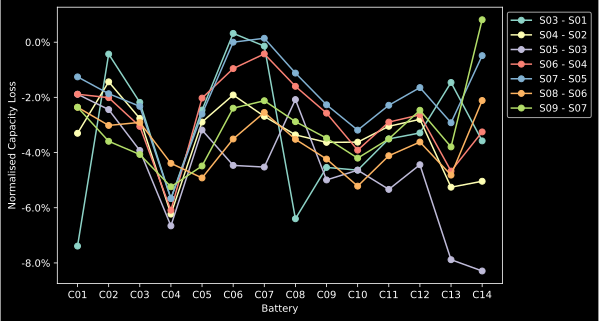

In [51]:
# S02 - S00, S04 - S01, S06 - S03, etc.

dod_data_by_stage_normalised_diff_same_time = dod_data_by_stage_normalised.diff(
    2,
    axis=0,
)
dod_data_by_stage_normalised_diff_same_time = (
    dod_data_by_stage_normalised_diff_same_time.dropna(axis=0, how="all")
)
dod_data_by_stage_normalised_diff_same_time = (
    dod_data_by_stage_normalised_diff_same_time.transpose()
)
dod_data_by_stage_normalised_diff_same_time = (
    dod_data_by_stage_normalised_diff_same_time.rename(
        columns={
            "S03": "S03 - S01",
            "S04": "S04 - S02",
            "S05": "S05 - S03",
            "S06": "S06 - S04",
            "S07": "S07 - S05",
            "S08": "S08 - S06",
            "S09": "S09 - S07",
        }
    )
)
dod_data_by_stage_normalised_diff_same_time = (
    dod_data_by_stage_normalised_diff_same_time[
        dod_data_by_stage_normalised_diff_same_time.columns[
            dod_data_by_stage_normalised_diff_same_time.columns.str.contains(
                "S0[3456789] - S0[1234567]"
            )
        ]
    ]
)

_ = plot_dod_line(
    dod_data_by_stage_normalised_diff_same_time,
    ylabel="Normalised Capacity Loss",
    yaxis_formatter=plt.FuncFormatter(lambda x, _: f"{x:.1%}"),
)